In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier


from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score , classification_report

In [4]:
import torch

torch.set_num_threads(4)

In [5]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 1
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [6]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.11.0+cu128
12.8
True


In [7]:
# %pip uninstall torch torchvision torchaudio -y

In [8]:
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [9]:
from transformers import AutoTokenizer , AutoModel

c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
train = pd.read_csv(
    "twitter_training.csv",
    names = ["id" , "entity" , "sentiment" , "text"]
    )
val = pd.read_csv(
    "twitter_validation.csv",
    names = ["id" , "entity" , "sentiment" , "text"]
    )

In [11]:
print(f"Train Shape : {train.shape}")
print(f"Validation Shape : {val.shape}")

Train Shape : (74682, 4)
Validation Shape : (1000, 4)


In [12]:
train.head()

,id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [13]:
val.head()

,id,entity,sentiment,text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [14]:
sentiment_count = train["sentiment"].value_counts()
sentiment_count

sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

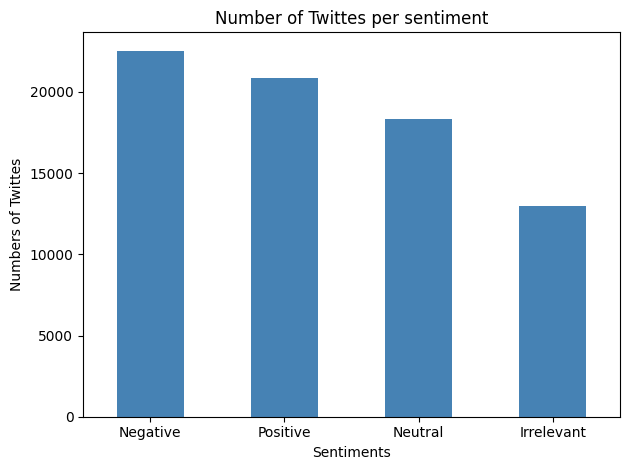

In [15]:
sentiment_count.plot(kind="bar" ,  color="steelblue")
plt.title("Number of Twittes per sentiment")
plt.xlabel("Sentiments")
plt.ylabel("Numbers of Twittes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
# Removing Rows where Text is missing
train_df = train.dropna(subset=["text"])
val_df = val.dropna(subset=["text"])

# make sure that each text is string
train_df["text"] = train_df["text"].astype(str)
val_df["text"] = val_df["text"].astype(str)

# keep only positive and negative tweets , drop Neutral and Irrelevent
labels_to_keep = ["Positive" , "Negative"]

train_df = train_df[ train_df["sentiment"].isin(labels_to_keep) ]
test_df = val_df[ val_df["sentiment"].isin(labels_to_keep) ]

print(f"Training Rows after Cleaning : {train_df.shape}")
print(f"Validation Rows after Cleaning : {val_df.shape}")

Training Rows after Cleaning : (43013, 4)
Validation Rows after Cleaning : (1000, 4)


In [17]:
train_df["sentiment"].value_counts()

sentiment
Negative    22358
Positive    20655
Name: count, dtype: int64

In [18]:
train_sample = train_df.sample(n=30000 , random_state=42)
test_sample = test_df

print(f"train_sample : {train_sample.shape}")
print(f"test_sample : {test_sample.shape}")

train_sample : (30000, 4)
test_sample : (543, 4)


### BERT -> bert-base-uncased

In [19]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased")

# use GPU if one is available , otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
bert_model = bert_model.to(device)

# put the model in evaluation mode because we are not training BERT
bert_model.eval()

print("BERT is loaded and running on :",  device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6105.60it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT is loaded and running on : cuda


#### Generate Embeddings

In [20]:
# This function takes a list of texts and returns their BERT embeddings

def get_embeddings(texts, batch_size=32):

    all_embeddings = []

    # Go through the texts a few at a time
    for start in range(0, len(texts), batch_size):

        batch = texts[start:start + batch_size]

        # Convert words into token numbers that BERT understands
        tokens = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=64,
            return_tensors="pt"
        )

        # Move tokens to GPU
        tokens = {key: value.to(device) for key, value in tokens.items()}

        # Ask BERT to read the tokens without training/updating BERT
        with torch.no_grad():

            output = bert_model(**tokens)

        # Take the CLS token as the representation of the whole text
        cls_vectors = output.last_hidden_state[:, 0, :]

        # Move embeddings from GPU to CPU and convert to NumPy
        cls_vectors = cls_vectors.cpu().numpy()

        # Store this batch
        all_embeddings.append(cls_vectors)

    # Combine all batches into one NumPy array
    embeddings = np.vstack(all_embeddings)

    return embeddings

In [21]:
train_texts = train_sample["text"].tolist()
test_texts = test_sample["text"].tolist()

X_train = get_embeddings(train_texts)

X_test = get_embeddings(test_texts)

print(f"Shape of traning embeddings : {X_train.shape}")
print(f"Shape of testing embeddings : {X_test.shape}")

Shape of traning embeddings : (30000, 768)
Shape of testing embeddings : (543, 768)


In [22]:
label_encoder = LabelEncoder()
label_encoder.fit(train_sample["sentiment"])

# turn the sentiment words into numbers
y_train = label_encoder.transform(train_sample["sentiment"])
y_test = label_encoder.transform(test_sample["sentiment"])

# show which number stands for which sentiment
print("Label mapping:")
for number, name in enumerate(label_encoder.classes_):
    print(number, "->", name)

Label mapping:
0 -> Negative
1 -> Positive


In [23]:
X_train[:5]

array([[ 0.14683048,  0.15640084,  0.10718698, ..., -0.37484866,
         0.48272192,  0.61913246],
       [-0.13488236, -0.2893719 ,  0.49753746, ..., -0.38087222,
         0.3861095 ,  0.30871555],
       [-0.02634625,  0.03419616, -0.40358147, ..., -0.34606272,
         0.43117264,  0.38534072],
       [-0.1864568 , -0.06916929, -0.0527474 , ..., -0.38971758,
         0.28725106,  0.2683801 ],
       [-0.06821168,  0.02091833,  0.1861624 , ..., -0.13078217,
         0.47197074,  0.32003003]], shape=(5, 768), dtype=float32)

# Model Training

In [27]:
results = {}

def train_and_check(model , model_name):

    # Train the model on the training embeddings and labels
    model.fit(X_train , y_train)

    # Prediction
    predictions = model.predict(X_test)

    # Evaluation Metrics
    accuracy = accuracy_score(y_test , predictions)
    print(f"{model_name} accuracy : {accuracy:.4f}\n")
    print(classification_report(y_test , predictions , target_names=label_encoder.classes_ ))

    results[model_name] = accuracy

    return model

### Logistic Regression : Baseline model

In [28]:
logistic_model = LogisticRegression(max_iter=1000)
train_and_check(logistic_model , "Logistic Regression")

Logistic Regression accuracy : 0.8214

              precision    recall  f1-score   support

    Negative       0.80      0.85      0.82       266
    Positive       0.85      0.79      0.82       277

    accuracy                           0.82       543
   macro avg       0.82      0.82      0.82       543
weighted avg       0.82      0.82      0.82       543



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### RandomForest

In [30]:
random_forest_model = RandomForestClassifier(n_estimators=200 , random_state=42)
train_and_check(random_forest_model , "RandomForest Classifier")

RandomForest Classifier accuracy : 0.9153

              precision    recall  f1-score   support

    Negative       0.90      0.94      0.92       266
    Positive       0.94      0.90      0.92       277

    accuracy                           0.92       543
   macro avg       0.92      0.92      0.92       543
weighted avg       0.92      0.92      0.92       543



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### XGBoost

In [31]:
xgboost_model = XGBClassifier(
    n_estimators = 200,
    eval_metric="mlogloss",
    random_state=42
)
train_and_check(xgboost_model , "XGBoost Classifier")

XGBoost Classifier accuracy : 0.9245

              precision    recall  f1-score   support

    Negative       0.92      0.93      0.92       266
    Positive       0.93      0.92      0.93       277

    accuracy                           0.92       543
   macro avg       0.92      0.92      0.92       543
weighted avg       0.92      0.92      0.92       543



,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### LightGBM

In [32]:
lightgbm_model = LGBMClassifier(
    n_estimators=200,
    random_state=42
)

train_and_check(lightgbm_model , "LightGBM")

[LightGBM] [Info] Number of positive: 14448, number of negative: 15552
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.097743 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 30000, number of used features: 768
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.481600 -> initscore=-0.073633
[LightGBM] [Info] Start training from score -0.073633
LightGBM accuracy : 0.8969

              precision    recall  f1-score   support

    Negative       0.88      0.91      0.90       266
    Positive       0.91      0.88      0.90       277

    accuracy                           0.90       543
   macro avg       0.90      0.90      0.90       543
weighted avg       0.90      0.90      0.90       543



,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### CatBoost

In [33]:
catboost_model = CatBoostClassifier(
    n_estimators=200,
    random_state=42,
    verbose=0
)
train_and_check(catboost_model , "Catboost")

Catboost accuracy : 0.8803

              precision    recall  f1-score   support

    Negative       0.87      0.89      0.88       266
    Positive       0.89      0.87      0.88       277

    accuracy                           0.88       543
   macro avg       0.88      0.88      0.88       543
weighted avg       0.88      0.88      0.88       543



CatBoostClassifier(n_estimators=200, random_state=42, verbose=0)

### Model performance Comparision

In [44]:
res = [results]
pd.DataFrame(
    res,
    index=["Accuracy"]
).T

,Accuracy
Logistic Regression,0.821363
RandomForest Classifier,0.915285
XGBoost Classifier,0.924494
LightGBM,0.896869
Catboost,0.880295
